In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import gc
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [8]:
import os
import pandas as pd

# Update the dataset path to point to your dataset folder
dataset_path = r"C:\Users\Collin Kliveson\Documents\kuliah\Image Processing\dataset\data"

# Create an empty list to store the data
data = []

# Loop through both 'train' and 'val' folders
for folder in ['train']:
    folder_path = os.path.join(dataset_path, folder)  # Full path to the train/val folder
    
    for category in os.listdir(folder_path):
        category_path = os.path.join(folder_path, category)
        
        if os.path.isdir(category_path):  # Check if it's a category folder
            for image_name in os.listdir(category_path):
                image_path = os.path.join(category_path, image_name)
                
                # Append the image path and category to the data list
                data.append({"image_path": image_path, "category": category})

# Create a pandas DataFrame to store the data
df = pd.DataFrame(data)

# Specify the output CSV file path where you want to save the result
output_csv = r"C:\Users\Collin Kliveson\Documents\kuliah\Image Processing\dataset.csv"
df.to_csv(output_csv, index=False)

print(f"CSV file saved as {output_csv}")


CSV file saved as C:\Users\Collin Kliveson\Documents\kuliah\Image Processing\dataset.csv


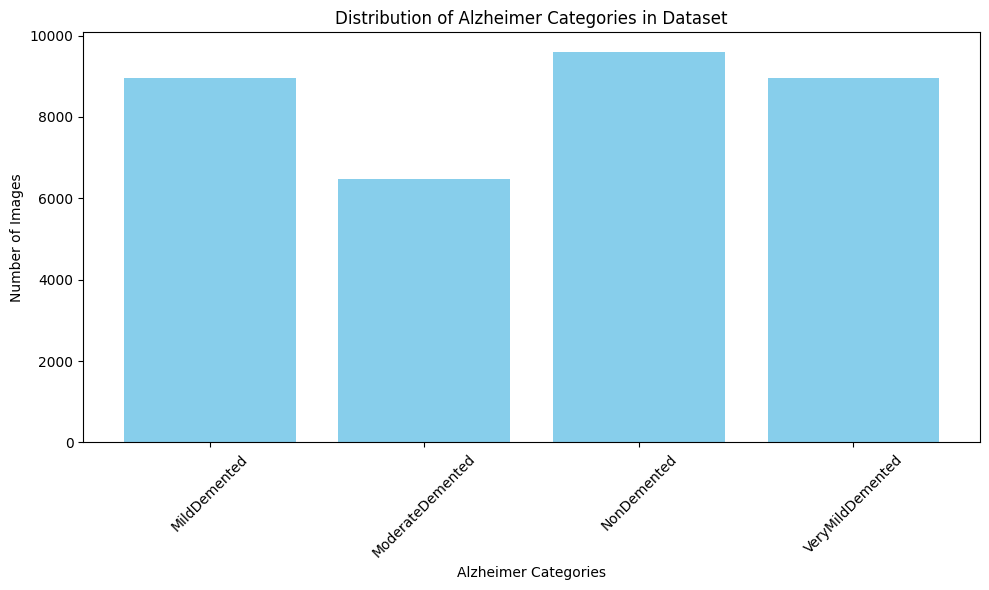

In [ ]:
import os
import matplotlib.pyplot as plt


train_dir = 'train'  

# Classes
categories = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Empty List
image_counts = []

# Loop through each category
for category in categories:
    category_path = os.path.join(train_dir, category)
    image_count = len([f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))])
    image_counts.append(image_count)

# Bar Plot
plt.figure(figsize=(10, 6))
plt.bar(categories, image_counts, color='skyblue')
plt.xlabel('Alzheimer Categories')
plt.ylabel('Number of Images')
plt.title('Distribution of Alzheimer Categories in Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


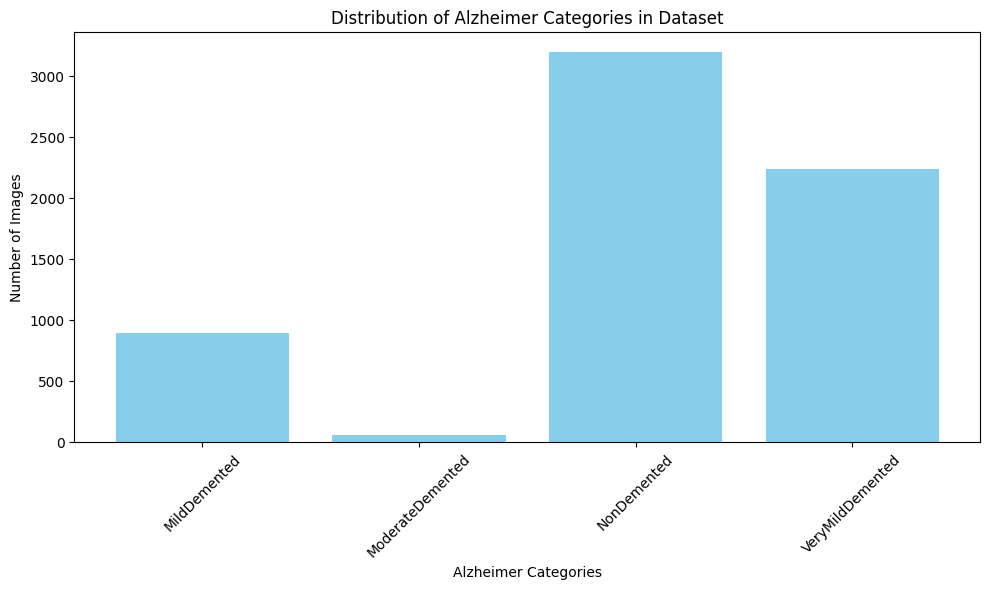

In [3]:
import os
import matplotlib.pyplot as plt

# Define the path to the 'train' directory
train_dir = 'val'  # Replace this with your actual path

# Define the categories in the folder
categories = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Initialize an empty list to store the count of images for each category
image_counts = []

# Loop through each category and count the number of files in each subfolder
for category in categories:
    category_path = os.path.join(train_dir, category)
    image_count = len([f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))])
    image_counts.append(image_count)

# Create a bar plot to visualize the number of images in each category
plt.figure(figsize=(10, 6))
plt.bar(categories, image_counts, color='skyblue')
plt.xlabel('Alzheimer Categories')
plt.ylabel('Number of Images')
plt.title('Distribution of Alzheimer Categories in Dataset')
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()


In [9]:
df.head()

,image_path,category
0,C:\Users\Collin Kliveson\Documents\kuliah\Imag...,MildDemented
1,C:\Users\Collin Kliveson\Documents\kuliah\Imag...,MildDemented
2,C:\Users\Collin Kliveson\Documents\kuliah\Imag...,MildDemented
3,C:\Users\Collin Kliveson\Documents\kuliah\Imag...,MildDemented
4,C:\Users\Collin Kliveson\Documents\kuliah\Imag...,MildDemented


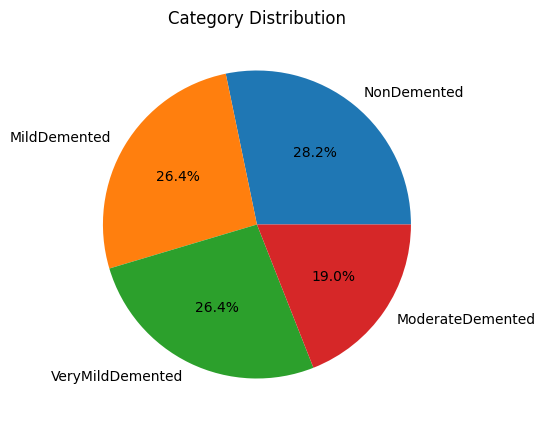

In [10]:
category_counts = df["category"].value_counts()

plt.figure(figsize=(12, 5))
plt.pie(category_counts, labels=category_counts.index, autopct="%1.1f%%")
plt.title("Category Distribution")
plt.show()

In [12]:
import os
import pandas as pd

# Update the dataset path to point to your dataset folder
dataset_path = r"C:\Users\Collin Kliveson\Documents\kuliah\Image Processing\dataset\data"

# Create an empty list to store the data
data = []

# Loop through both 'train' and 'val' folders
for folder in ['val']:
    folder_path = os.path.join(dataset_path, folder)  # Full path to the train/val folder
    
    for category in os.listdir(folder_path):
        category_path = os.path.join(folder_path, category)
        
        if os.path.isdir(category_path):  # Check if it's a category folder
            for image_name in os.listdir(category_path):
                image_path = os.path.join(category_path, image_name)
                
                # Append the image path and category to the data list
                data.append({"image_path": image_path, "category": category})

# Create a pandas DataFrame to store the data
df2 = pd.DataFrame(data)

# Specify the output CSV file path where you want to save the result
output_csv = r"C:\Users\Collin Kliveson\Documents\kuliah\Image Processing\test_dataset.csv"
df2.to_csv(output_csv, index=False)

print(f"CSV file saved as {output_csv}")


CSV file saved as C:\Users\Collin Kliveson\Documents\kuliah\Image Processing\test_dataset.csv


In [13]:
df2.head()

,image_path,category
0,C:\Users\Collin Kliveson\Documents\kuliah\Imag...,MildDemented
1,C:\Users\Collin Kliveson\Documents\kuliah\Imag...,MildDemented
2,C:\Users\Collin Kliveson\Documents\kuliah\Imag...,MildDemented
3,C:\Users\Collin Kliveson\Documents\kuliah\Imag...,MildDemented
4,C:\Users\Collin Kliveson\Documents\kuliah\Imag...,MildDemented


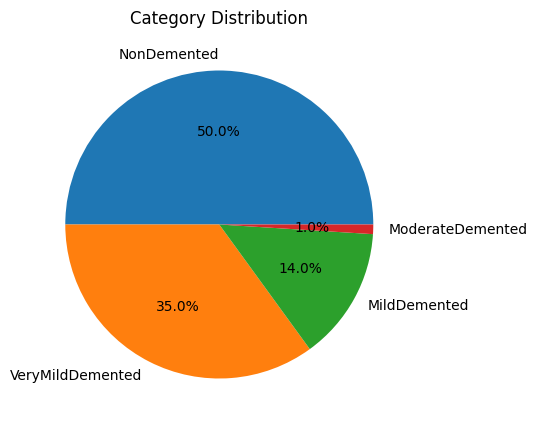

In [14]:
category_counts = df2["category"].value_counts()

plt.figure(figsize=(12, 5))
plt.pie(category_counts, labels=category_counts.index, autopct="%1.1f%%")
plt.title("Category Distribution")
plt.show()

In [15]:
def show_random_images(column, number_of_images_to_show=5, grey=False):
    categories = df["category"].unique()
    
    images_per_category = number_of_images_to_show
    
    plt.figure(figsize=(15, len(categories) * 5))
    for i, category in enumerate(categories):
        category_images = df[df["category"] == category][column].tolist()
        
        for j in range(min(len(category_images), images_per_category)):
            img_data = category_images[j]
            if column != "image_path":
                img = img_data
            else:
                img = cv2.imread(img_data)
                
            if column == "image_path":
                if grey:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.subplot(len(categories), images_per_category, i * images_per_category + j + 1)
            
            if grey:
                plt.imshow(img, cmap="gray")
            else:
                plt.imshow(img)
            
            plt.axis("off")
            plt.title(f"{category}")
    
    plt.tight_layout()
    plt.show()

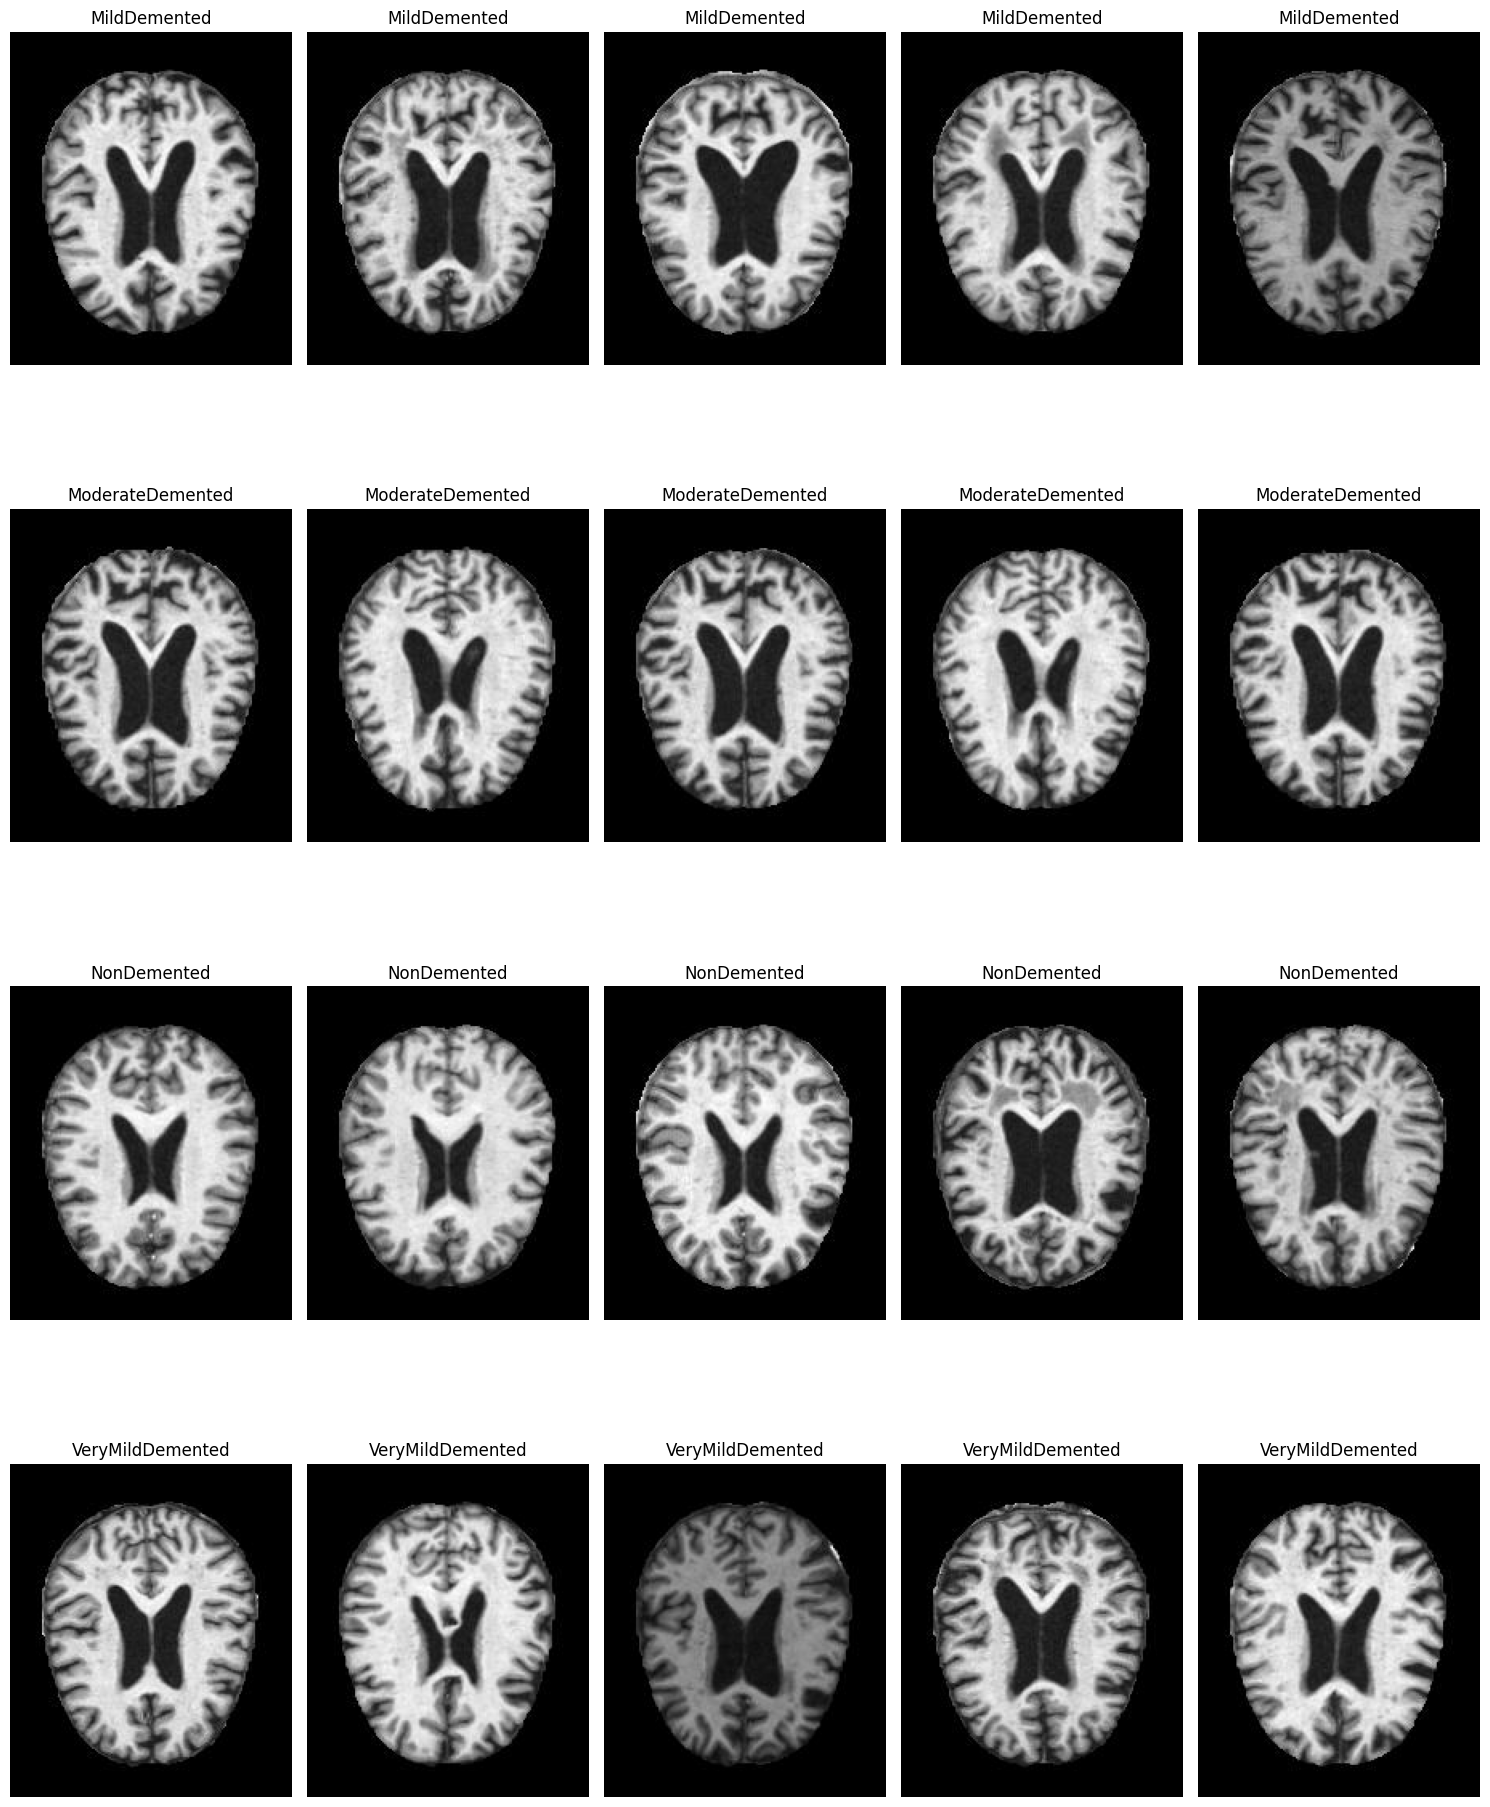

In [18]:
show_random_images("image_path", 5, False)

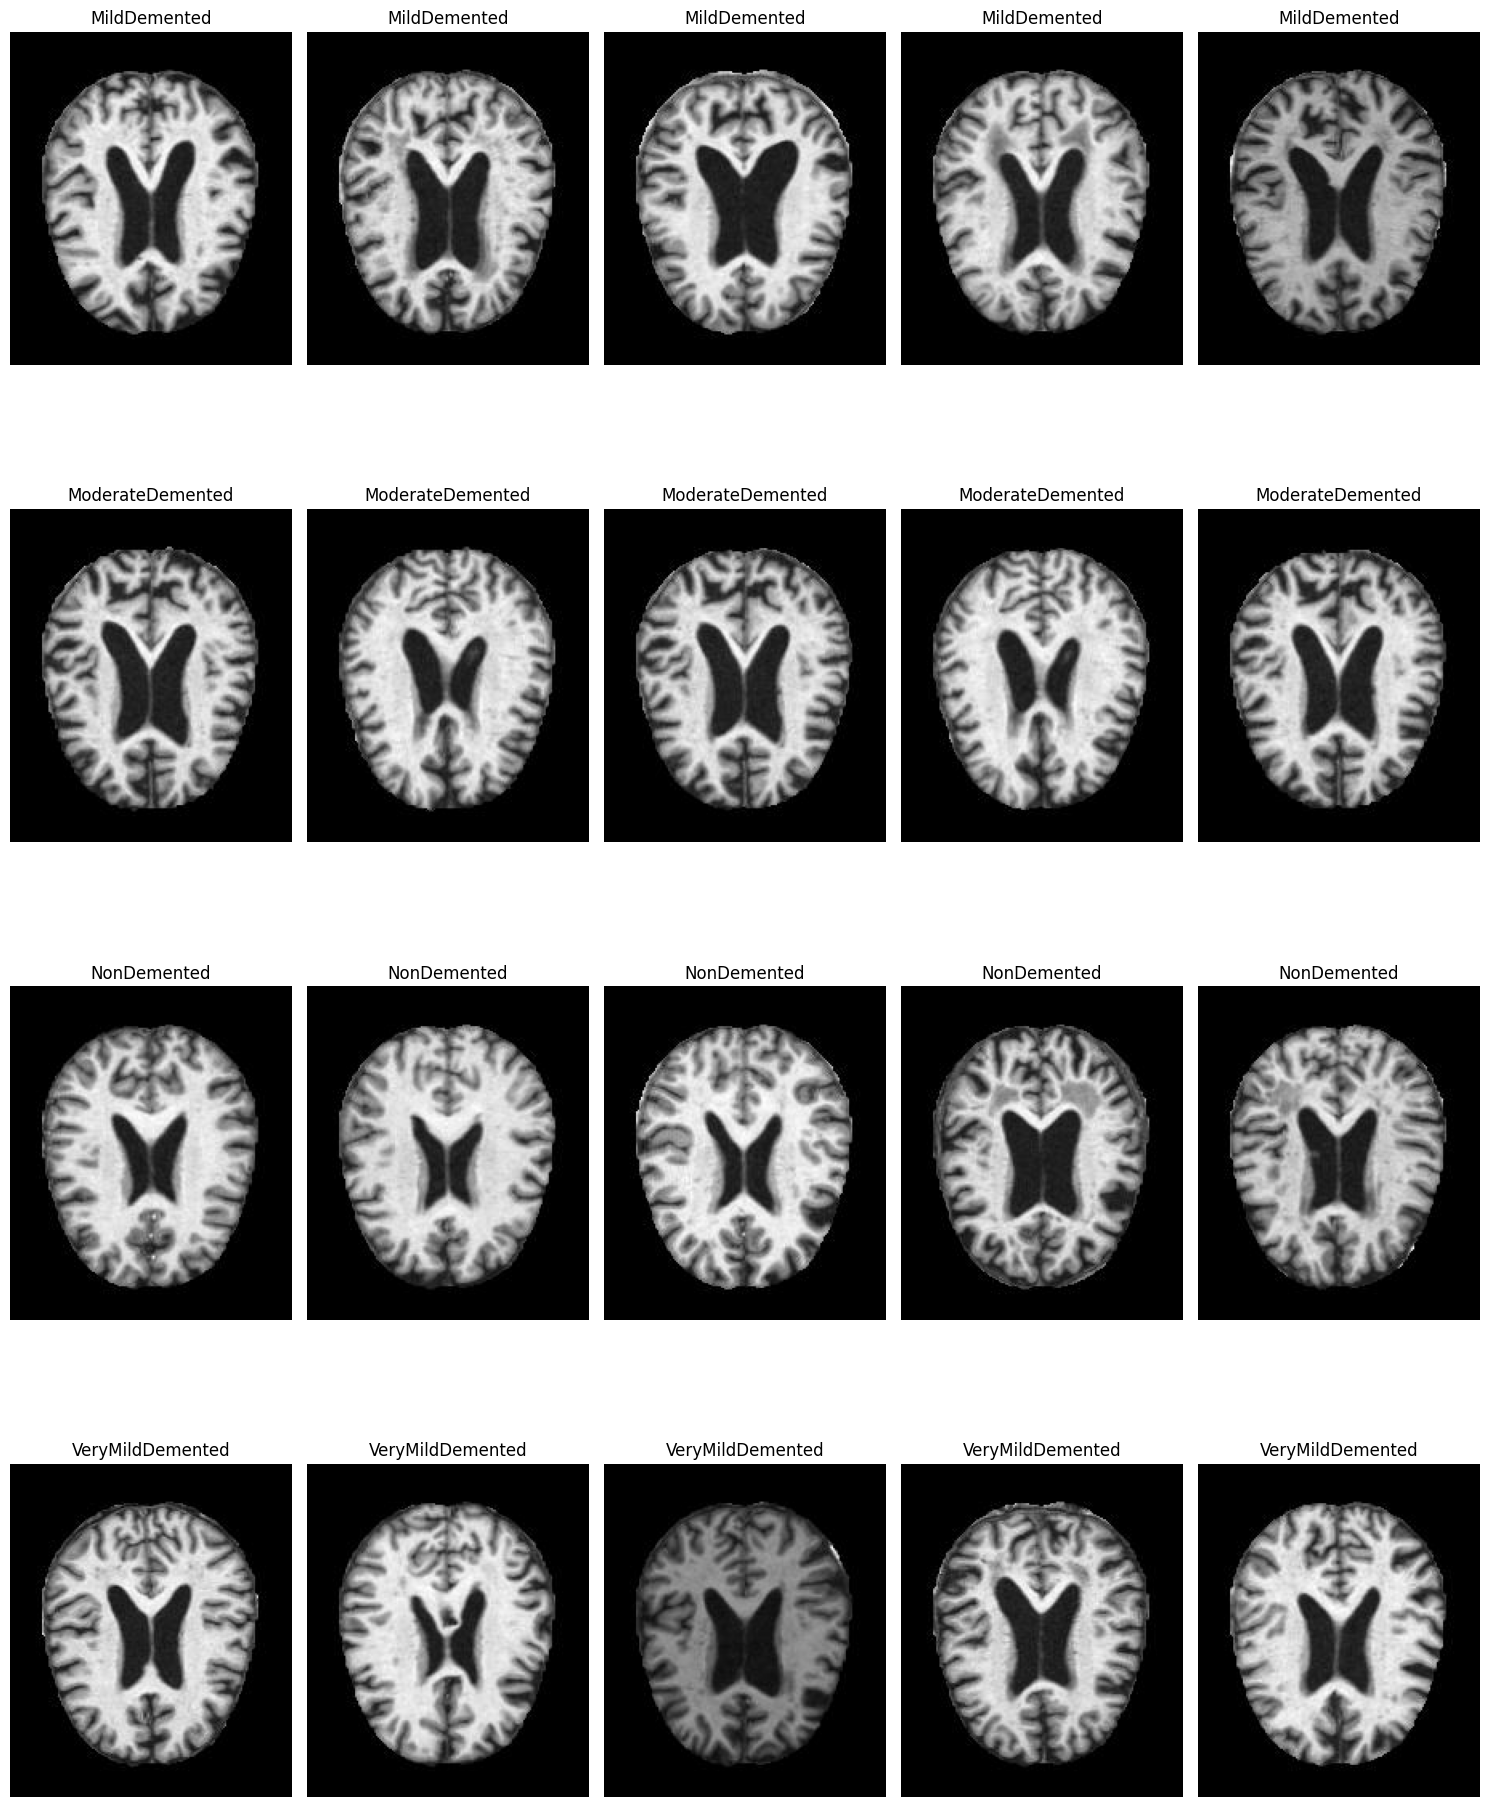

In [20]:
show_random_images("image_path", 5, True)

In [21]:
min_dim = cv2.imread(df["image_path"][0])
min_height, min_width = min_dim.shape[:2]

for image_path in df["image_path"]:
    img = cv2.imread(image_path)
    height, width = img.shape[:2]
    min_height = min(min_height, height)
    min_width = min(min_width, width)
print(min_height)
print(min_width)

208
176


In [22]:
min_dim = cv2.imread(df2["image_path"][0])
min_height, min_width = min_dim.shape[:2]

for image_path in df2["image_path"]:
    img = cv2.imread(image_path)
    height, width = img.shape[:2]
    min_height = min(min_height, height)
    min_width = min(min_width, width)
print(min_height)
print(min_width)

208
176
